# Avance 3. Baseline


El propósito de este notebook es establecer un modelo de referencia (baseline) para el pronóstico de la serie temporal de casos de depresión. Un modelo de referencia es fundamental en cualquier proyecto de machine learning porque:

1. Establece un punto de comparación: Sirve como una medida de rendimiento mínima que cualquier modelo más complejo (como SARIMA o modelos de machine learning) debe superar para justificar su complejidad.

2. Valida el entendimiento de los datos: Un buen modelo base demuestra que se han comprendido las características principales de la serie, como la tendencia y la estacionalidad.

## Librerías y Carga de Datos

* Se define si se utilizará Plotly para las gráficas y se importan las librerías necesarias para análisis de datos, visualización y modelado de series temporales.

Recomendaciones:  Para un mejor entendimiento de las gráficas o su uso local cambiar el valor de `USE_PLOTRLY` a `True`

In [1]:
USE_PLOTLY = True

### Librerías

In [2]:
import sys
sys.path.append('../../')

In [3]:
import pandas as pd
import numpy as np
from tabulate import tabulate
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# !pip install holidays
from src.utils import helpers as func
from src.utils.ts_diagnostics import StationarityAnalyzer, analyze_decomposition

# !pip install prince
import prince as pr
import plotly.express as px

### Carga de Datos

* Se carga el conjunto de datos procesado utilizando una función personalizada, preparando el DataFrame para el análisis.

In [4]:
# path = '../../data/processed/df_entidades_acum.parquet'
path = '../../data/processed/df_acumulado.parquet'
df = func.load_data(path,show_info=False)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Datos cargados exitosamente.


## Análisis de la Serie Temporal

### Serie Original por Casos Semanales Acumulados

* Se seleccionan las columnas relevantes y se grafica la serie temporal acumulada para observar su comportamiento general.

In [5]:
# Dataframe con las columnas necesarias para el análisis de series temporales
df_filtrado = df[['fecha', 'valor_acumulado_corregido']].copy()
df_filtrado.rename(columns={'valor_acumulado_corregido': 'valor'}, inplace=True)
x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General acumulada (df_final)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_filtrado, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

#### Descripción de gráfico
Se realizaron las correcciones pertinentes al dataset para considerar los valores acumulados de todos los años pasados y se corrigieron los valores atípicos con interpolación. con ellos, se obtiene el gráfico mostrado arriba, en el cual, se puede confirmar que la serie temporal de casos de depresión exhibe una **fuerte y consistente tendencia de crecimiento** desde 2014. Esto valida que el ritmo constante de acumulación de casos a lo largo del tiempo es el patrón "normal". La serie es altamente predecible en su tendencia.

#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [6]:
ts_data = df_filtrado.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data.head())

Serie temporal preparada para descomposición:


fecha
2014-01-06     131.0
2014-01-13     789.0
2014-01-20    1722.0
2014-01-27    2745.0
2014-02-03    3896.0
Name: valor, dtype: float64

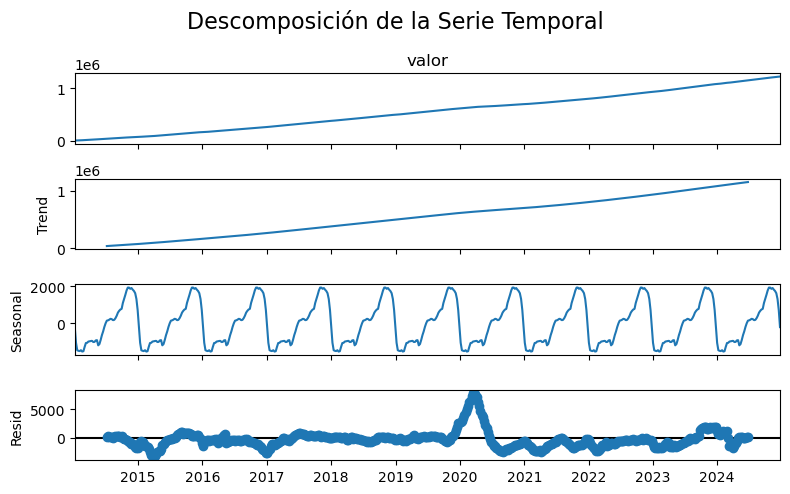

In [7]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie**

**Tendencia (Trend):** 

**Estacionalidad (Seasonal):** 

**Residuos (Resid):** 

La serie de tiempo es **altamente predecible**. Está dominada por una **tendencia de crecimiento lineal** y una **estacionalidad anual clara**. Al corregir los valores atípicos, el modelo de descomposición es robusto y los componentes quedan bien separados, lo que es ideal para aplicar modelos de pronóstico como SARIMA.

#### Pruebas de estacionaridad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [8]:
tester_ts_data = StationarityAnalyzer(ts_data)

tester_ts_data.run_test(test_type='ADF', show_report=True)
tester_ts_data.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │         3.3382 │                -2.8666 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         1      │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         3.4534 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.01   │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


d:\MNA\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




##### Análisis de Resultados: Prueba ADF

¿¿¿¿


##### Análisis de Resultados: Prueba KPSS

¿¿¿¿

### Serie Original por Casos Semanales

* Se seleccionan las columnas relevantes y se grafica la serie temporal acumulada para observar su comportamiento general.

In [9]:
df_incremento = df_filtrado.copy()
df_incremento['valor'] = df_incremento['valor'].diff().fillna(0)
df_incremento.iloc[0, df_incremento.columns.get_loc('valor')] = 131

x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_incremento, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

#### Descripción de gráfico
Se realizaron las correcciones pertinentes al dataset para considerar los valores acumulados de todos los años pasados y se corrigieron los valores atípicos con interpolación. con ellos, se obtiene el gráfico mostrado arriba, en el cual, se puede confirmar que la serie temporal de casos de depresión exhibe una **fuerte y consistente tendencia de crecimiento** desde 2014. Esto valida que el ritmo constante de acumulación de casos a lo largo del tiempo es el patrón "normal". La serie es altamente predecible en su tendencia.

#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [10]:
ts_data_incremento = df_incremento.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_incremento.head())

Serie temporal preparada para descomposición:


fecha
2014-01-06     131.0
2014-01-13     658.0
2014-01-20     933.0
2014-01-27    1023.0
2014-02-03    1151.0
Name: valor, dtype: float64

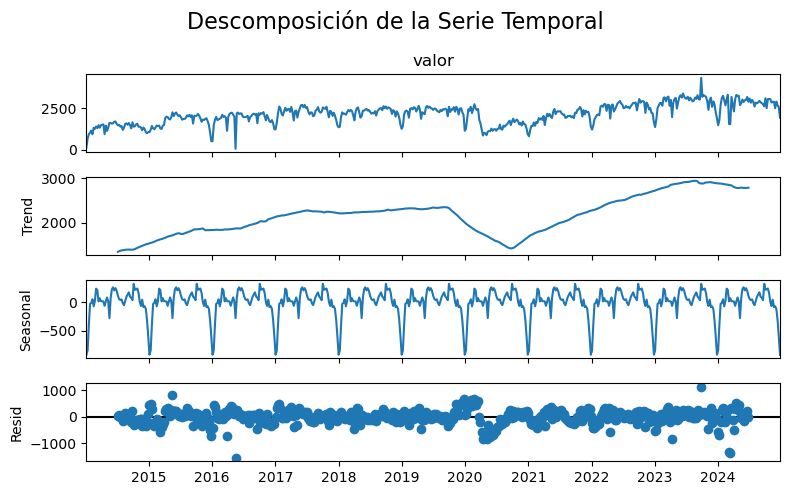

In [11]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_incremento, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie**

**Tendencia (Trend):** 

**Estacionalidad (Seasonal):** 

**Residuos (Resid):** 

La serie de tiempo es **altamente predecible**. Está dominada por una **tendencia de crecimiento lineal** y una **estacionalidad anual clara**. Al corregir los valores atípicos, el modelo de descomposición es robusto y los componentes quedan bien separados, lo que es ideal para aplicar modelos de pronóstico como SARIMA.

#### Pruebas de estacionaridad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [12]:
tester_ts_data_incremento = StationarityAnalyzer(ts_data_incremento)

tester_ts_data_incremento.run_test(test_type='ADF', show_report=True)
tester_ts_data_incremento.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -2.577  │                -2.8667 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0.0978 │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         1.8196 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.01   │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


d:\MNA\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




##### Análisis de Resultados: Prueba ADF

¿¿¿¿


##### Análisis de Resultados: Prueba KPSS

¿¿¿¿

### Serie Original por Casos Semanales (log)

* Se seleccionan las columnas relevantes y se grafica la serie temporal acumulada para observar su comportamiento general.

In [13]:
df_log = df_incremento.copy()
df_log['valor'] = np.log1p(df_log['valor'])
x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_log, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

#### Descripción de gráfico
Se realizaron las correcciones pertinentes al dataset para considerar los valores acumulados de todos los años pasados y se corrigieron los valores atípicos con interpolación. con ellos, se obtiene el gráfico mostrado arriba, en el cual, se puede confirmar que la serie temporal de casos de depresión exhibe una **fuerte y consistente tendencia de crecimiento** desde 2014. Esto valida que el ritmo constante de acumulación de casos a lo largo del tiempo es el patrón "normal". La serie es altamente predecible en su tendencia.

#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [14]:
ts_data_log = df_log.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_log.head())

Serie temporal preparada para descomposición:


fecha
2014-01-06    4.882802
2014-01-13    6.490724
2014-01-20    6.839476
2014-01-27    6.931472
2014-02-03    7.049255
Name: valor, dtype: float64

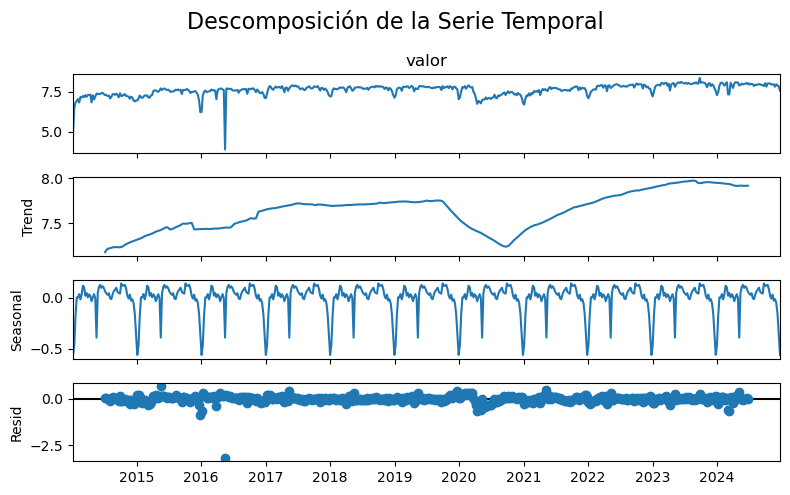

In [15]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_log, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie**

**Tendencia (Trend):** 

**Estacionalidad (Seasonal):** 

**Residuos (Resid):** 

La serie de tiempo es **altamente predecible**. Está dominada por una **tendencia de crecimiento lineal** y una **estacionalidad anual clara**. Al corregir los valores atípicos, el modelo de descomposición es robusto y los componentes quedan bien separados, lo que es ideal para aplicar modelos de pronóstico como SARIMA.

#### Pruebas de estacionaridad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [16]:
tester_ts_data_log = StationarityAnalyzer(ts_data_log)

tester_ts_data_log.run_test(test_type='ADF', show_report=True)
tester_ts_data_log.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -4.223  │                -2.8667 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0.0006 │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         1.7704 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.01   │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


d:\MNA\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




##### Análisis de Resultados: Prueba ADF

¿¿¿¿


##### Análisis de Resultados: Prueba KPSS

¿¿¿¿

### Serie Original por Casos Semanales (Box-Cox)

* Se seleccionan las columnas relevantes y se grafica la serie temporal acumulada para observar su comportamiento general.

In [17]:
from scipy import stats
df_boxcox = df_incremento.copy()
serie_transformada, lambda_optimo = stats.boxcox(df_boxcox['valor'])
df_boxcox['valor'] = serie_transformada

x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_boxcox, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

#### Descripción de gráfico
Se realizaron las correcciones pertinentes al dataset para considerar los valores acumulados de todos los años pasados y se corrigieron los valores atípicos con interpolación. con ellos, se obtiene el gráfico mostrado arriba, en el cual, se puede confirmar que la serie temporal de casos de depresión exhibe una **fuerte y consistente tendencia de crecimiento** desde 2014. Esto valida que el ritmo constante de acumulación de casos a lo largo del tiempo es el patrón "normal". La serie es altamente predecible en su tendencia.

#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [18]:
ts_data_boxcox = df_boxcox.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_boxcox.head())

Serie temporal preparada para descomposición:


fecha
2014-01-06     265.810944
2014-01-13    1789.200275
2014-01-20    2701.687877
2014-01-27    3011.824805
2014-02-03    3461.348526
Name: valor, dtype: float64

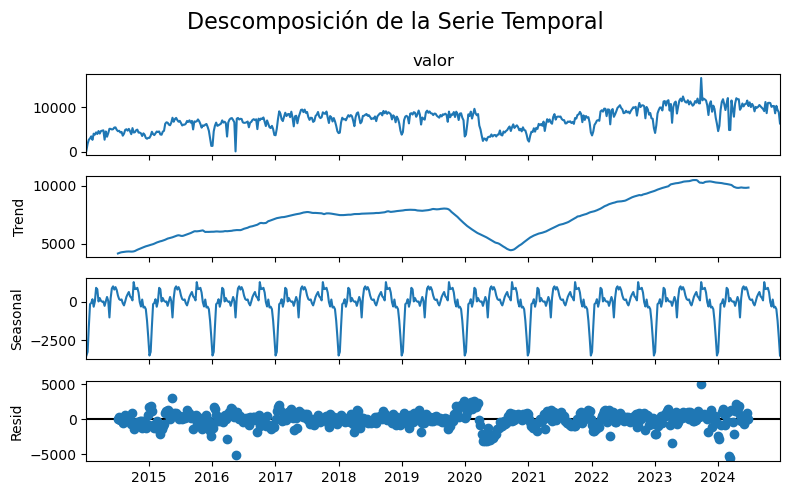

In [19]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_boxcox, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie**

**Tendencia (Trend):** 

**Estacionalidad (Seasonal):** 

**Residuos (Resid):** 

La serie de tiempo es **altamente predecible**. Está dominada por una **tendencia de crecimiento lineal** y una **estacionalidad anual clara**. Al corregir los valores atípicos, el modelo de descomposición es robusto y los componentes quedan bien separados, lo que es ideal para aplicar modelos de pronóstico como SARIMA.

#### Pruebas de estacionaridad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [20]:
tester_ts_data_boxcox = StationarityAnalyzer(ts_data_boxcox)

tester_ts_data_boxcox.run_test(test_type='ADF', show_report=True)
tester_ts_data_boxcox.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -2.215  │                -2.8668 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0.2008 │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         1.8468 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.01   │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


d:\MNA\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




##### Análisis de Resultados: Prueba ADF

¿¿¿¿


##### Análisis de Resultados: Prueba KPSS

¿¿¿¿

### Serie Original por Casos Semanales (log + Diff)

* Se seleccionan las columnas relevantes y se grafica la serie temporal acumulada para observar su comportamiento general.

In [21]:
df_log_diff = df_log.copy()
df_diff1 = df_log_diff.set_index('fecha').diff().dropna().reset_index()

x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_diff1, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

#### Descripción de gráfico
Se realizaron las correcciones pertinentes al dataset para considerar los valores acumulados de todos los años pasados y se corrigieron los valores atípicos con interpolación. con ellos, se obtiene el gráfico mostrado arriba, en el cual, se puede confirmar que la serie temporal de casos de depresión exhibe una **fuerte y consistente tendencia de crecimiento** desde 2014. Esto valida que el ritmo constante de acumulación de casos a lo largo del tiempo es el patrón "normal". La serie es altamente predecible en su tendencia.

#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [22]:
ts_data_diff1 = df_diff1.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_diff1.head())

Serie temporal preparada para descomposición:


fecha
2014-01-13    1.607922
2014-01-20    0.348753
2014-01-27    0.091995
2014-02-03    0.117783
2014-02-10   -0.216223
Name: valor, dtype: float64

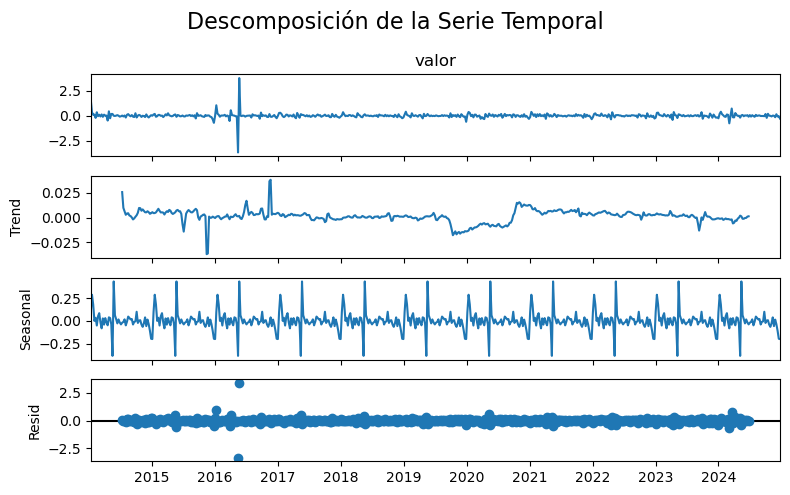

In [23]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_diff1, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie**

**Tendencia (Trend):** 

**Estacionalidad (Seasonal):** 

**Residuos (Resid):** 

La serie de tiempo es **altamente predecible**. Está dominada por una **tendencia de crecimiento lineal** y una **estacionalidad anual clara**. Al corregir los valores atípicos, el modelo de descomposición es robusto y los componentes quedan bien separados, lo que es ideal para aplicar modelos de pronóstico como SARIMA.

#### Pruebas de estacionaridad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [24]:
tester_ts_data_diff1 = StationarityAnalyzer(ts_data_diff1)

tester_ts_data_diff1.run_test(test_type='ADF', show_report=True)
tester_ts_data_diff1.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -7.9522 │                -2.8668 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0      │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         0.3101 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.1    │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


d:\MNA\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




##### Análisis de Resultados: Prueba ADF

¿¿¿¿


##### Análisis de Resultados: Prueba KPSS

¿¿¿¿

## Exponential Smoothing

In [25]:
# Se importa el modelo Holt de la librería statsmodels para aplicar suavizamiento exponencial doble.
from statsmodels.tsa.holtwinters import Holt

### Modelo Holt (df_log)

* Se ordena el DataFrame por fecha, se establece el índice temporal y se divide el conjunto de datos en entrenamiento (80%) y prueba (20%) para validar el modelo.

In [26]:
# índice temporal
df = df_log.copy()
data = df.sort_values('fecha').set_index('fecha').asfreq('W-MON')
# data = data.set_index('fecha').asfreq('W-MON')
train, test = func.split_series(data, train_size=0.8)

Total de datos: 573
Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115


* Se ajusta el modelo de suavizamiento exponencial doble utilizando únicamente el conjunto de entrenamiento.

In [27]:
# model_double = Holt(data)
model_double = Holt(train)
model_double_fit = model_double.fit()

* Se realiza el pronóstico para el periodo de prueba utilizando el modelo ajustado.

In [28]:
forecast_double = model_double_fit.forecast(115)
# print(forecast_double)

* Se transforman los valores ajustados y pronosticados de la escala logarítmica a la escala original para facilitar la interpretación

In [29]:
scaled_method = 'log'
df_original = func.get_original_scale_dataframe(data, method=scaled_method)
df_ajustado = func.get_original_scale_dataframe(model_double_fit.fittedvalues, method=scaled_method)
df_pronostico = func.get_original_scale_dataframe(forecast_double, method=scaled_method)

#### Visualización de resultados
* Se grafican los datos originales, los valores ajustados y el pronóstico para comparar el desempeño del modelo.

In [30]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'Modelo Holt / Double Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    'hover_mode': 'x unified',
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'valor_log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

#### Evaluación del modelo

Se calculan las métricas de error (MAE y RMSE) tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [31]:
func.evaluate_model_performance(train,test,df_ajustado,df_pronostico, label= 'valor')

Evaluating model performance...
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.142898 │
├───────────┼──────────┤
│ RMSE      │ 0.319797 │
╘═══════════╧══════════╛
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.967485 │
├───────────┼──────────┤
│ RMSE      │ 1.11136  │
╘═══════════╧══════════╛


In [32]:
func.plot_residuals_over_time(train,df_ajustado, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Entrenamiento')
func.plot_residuals_over_time(test, df_pronostico, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Prueba')

La evaluación del modelo muestra un bajo error absoluto medio (MAE) y raíz del error cuadrático medio (RMSE) tanto en el conjunto de entrenamiento como en el de prueba. Esto indica que el modelo de suavizamiento exponencial doble logra un ajuste preciso y generaliza adecuadamente a datos no vistos.

* Se genera un pronóstico adicional para un periodo más largo y se visualiza junto con los datos originales y ajustados.

In [33]:
forecast_double2 = model_double_fit.forecast(200)
df_pronostico2 = func.get_original_scale_dataframe(forecast_double2, method='log')

In [34]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'Modelo Holt / Double Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico2, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    'hover_mode': 'x unified',
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'valor_log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

## x

In [110]:
from statsmodels.tsa.api import ExponentialSmoothing

# índice temporal
# data = df_log.sort_values('fecha')
# data = df_filtrado.copy().sort_values('fecha')
data = df_log.copy().sort_values('fecha')
data = data.set_index('fecha').asfreq('W-MON')
train, test = func.split_series(data, train_size=0.8)


Total de datos: 573
Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115


In [111]:
model_triple = ExponentialSmoothing(
    train, 
    seasonal_periods=52, 
    trend='mul', 
    seasonal='add')

model_triple_fit = model_triple.fit()

In [112]:
# forecast_triple = model_triple_fit.forecast(115)
forecast_triple = model_triple_fit.forecast(115)


In [113]:
method = 'log'
df_original = func.get_original_scale_dataframe(data, method=method)

df_ajustado = func.get_original_scale_dataframe(model_triple_fit.fittedvalues, method=method)

df_pronostico = func.get_original_scale_dataframe(forecast_triple, method=method)

In [114]:
func.evaluate_model_performance(train,test,df_ajustado,df_pronostico, label= 'valor')

Evaluating model performance...
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.111671 │
├───────────┼──────────┤
│ RMSE      │ 0.225802 │
╘═══════════╧══════════╛
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.132012 │
├───────────┼──────────┤
│ RMSE      │ 0.188655 │
╘═══════════╧══════════╛


In [115]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'Holt-Winters / Triple Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    # 'hover_mode': 'x unified',
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

In [116]:
forecast_triple = model_triple_fit.forecast(200)
df_pronostico2 = func.get_original_scale_dataframe(forecast_triple, method=method)

In [117]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'Modelo Holt / Double Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico2, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    # 'hover_mode': 'x unified',
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

In [118]:
func.plot_residuals_over_time(train,df_ajustado, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Entrenamiento')
func.plot_residuals_over_time(test, df_pronostico, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Prueba')